# Machine Learning Classifier for Lung Disease

## Convolutional Neural Network

A convolutional neural network is a special type of neural network designed for identifying patterns in images by learning the filters found in images. 

In [2]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tqdm import tqdm

### Load Data set

The following code is to load the images into an array that can be passed through the tensorflow CNN architecture.

In [3]:
def load_lung_disease_dataset_cnn(base_path, img_size=(224, 224), clahe_on=True):
    data = []
    labels = []
    
    if not os.path.exists(base_path):
        print(f"Error: Path {base_path} not found.")
        return None, None
        
    class_names = sorted([f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))])
    
    if clahe_on:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    
    for idx, label in enumerate(class_names):
        folder_path = os.path.join(base_path, label)
        files = os.listdir(folder_path)
        
        for img_name in tqdm(files, desc=f"Loading {label}", leave=False):
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                continue
            
            if clahe_on:
                img = clahe.apply(img)
                
            img = cv2.resize(img, img_size)
            
            data.append(img / 255.0)
            labels.append(idx)
            
    return np.array(data, dtype=np.float32), np.array(labels, dtype=np.int32)

Contrast Limited Adaptive Histogram Equalization (CLAHE) is an advanced image processing technique that enhances local contrast by dividing images into small tiles and applying histogram equalization to each, rather than the whole image. This is ideal for the lung images to emphasize the details that would otherwise be overlooked. For the initial training of the model, this will be turned off. 

In [4]:
X, y = load_lung_disease_dataset_cnn('1/dataset_combined', clahe_on=False)

### Split Dataset
The data set is split three-Way (Train 70%, Val 15%, Test 15%) while ensuring that the split is stratified to avoid underrepresentation.

In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full
)

X_train = X_train.reshape(-1, 224, 224, 1)
X_val = X_val.reshape(-1, 224, 224, 1)
X_test = X_test.reshape(-1, 224, 224, 1)

This plot will show 25 examples taken from the dataset

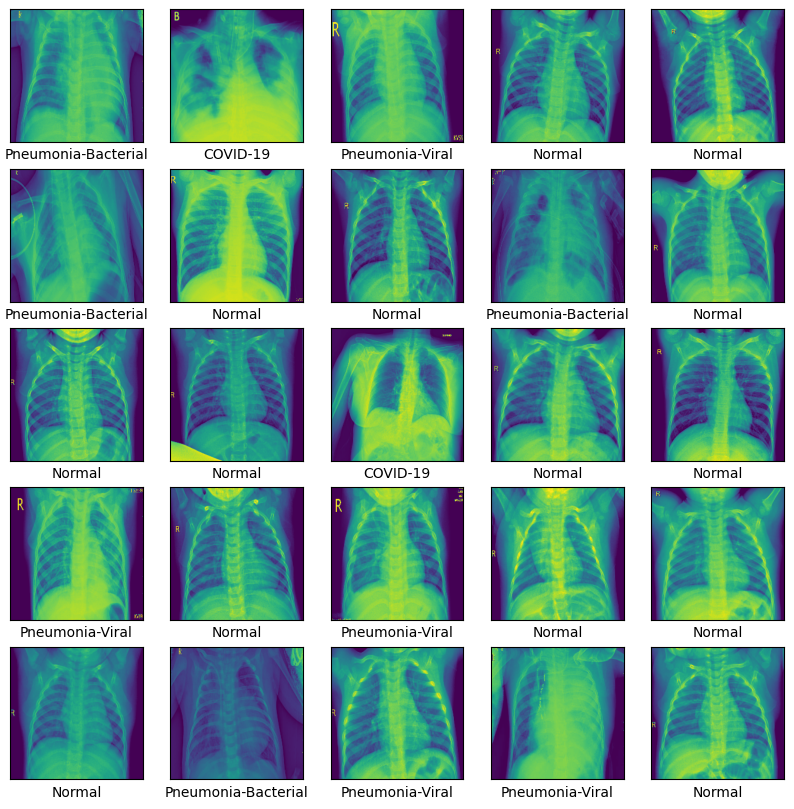

In [ ]:
classes = ["COVID-19", "Normal", "Pneumonia-Bacterial", "Pneumonia-Viral"]

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap='gray')
    plt.xlabel(classes[y_train[i]])
plt.show()

## Model construction
Below is a shallow CNN model with 3 convolutional layers and a maps them to 4 output classes through a dense bottleneck.

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(4))
model.summary()

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, 
                    validation_data=(X_val, y_val))

In [ ]:
print("\nEvaluating model on unseen Test Set...")
all_preds = model.predict(X_test)

predicted_classes = np.argmax(all_preds, axis=1)

print(classification_report(y_test, predicted_classes))

y_test_flat = y_test.flatten().astype(np.int32)

cm = confusion_matrix(y_test_flat, predicted_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Final Confusion Matrix")
plt.show()

In [ ]:
model.save('lung_disease_model_cnn_1.keras')

In [ ]:
X, y = load_lung_disease_dataset_cnn('1/dataset_combined')

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full
)

X_train = X_train.reshape(-1, 224, 224, 1)
X_val = X_val.reshape(-1, 224, 224, 1)
X_test = X_test.reshape(-1, 224, 224, 1)

In [ ]:
model_clahe = models.Sequential()
model_clahe.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)))
model_clahe.add(layers.MaxPooling2D((2, 2)))
model_clahe.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_clahe.add(layers.MaxPooling2D((2, 2)))
model_clahe.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_clahe.add(layers.Flatten())
model_clahe.add(layers.Dense(64, activation='relu'))
model_clahe.add(layers.Dense(4))

model_clahe.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model_clahe.fit(X_train, y_train, epochs=10, 
                    validation_data=(X_val, y_val))

In [ ]:
print("\nEvaluating model on unseen Test Set...")
all_preds = model_clahe.predict(X_test)

predicted_classes = np.argmax(all_preds, axis=1)

print(classification_report(y_test, predicted_classes))

y_test_flat = y_test.flatten().astype(np.int32)

cm = confusion_matrix(y_test_flat, predicted_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Final Confusion Matrix")
plt.show()